<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/Transfer_learning_Darrick_Pang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import optimizers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
import pandas as pd
from tensorflow.keras.constraints import max_norm
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, BackupAndRestore
from tensorflow.keras.applications.xception import preprocess_input

In [ ]:
lr1 = 1e-3
lr2 = 3e-4
results = []
batch_size = 64
target_size = 192
num_layers = 10
epochs = 10
weight_decay = 1e-4
warmup_epochs = 6                 # head-only
ft_epochs = 15                    # fine-tuning
base_lr = 3e-4                    # head-only LR
ft_lr = 2e-5

In [ ]:
# Load and preprocess the CIFAR-10 data

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.reshape((x_train.shape[0], 32, 32, 3)).astype("float32") / 255
x_test = x_test.reshape((x_test.shape[0], 32, 32, 3)).astype("float32") / 255

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Seperate validation data from training data
x_valid = x_train[:5000]
y_valid = y_train[:5000]
x_train = x_train[5000:]
y_train = y_train[5000:]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 35s 0us/step


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1)
])

In [ ]:
# Build the CNN model
base_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, 3, padding="same", use_bias=False, activation=None, kernel_constraint=max_norm(3., axis=[0,1,2])),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(32, 3, padding="same", use_bias=False, activation=None, kernel_constraint=max_norm(3., axis=[0,1,2])),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, padding="same", use_bias=False, activation=None, kernel_constraint=max_norm(3., axis=[0,1,2])),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(64, 3, padding="same", use_bias=False, activation=None, kernel_constraint=max_norm(3., axis=[0,1,2])),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(2),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, padding="same", use_bias=False, kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    # Flatten to feed MLP
    layers.Flatten(),

    # MLP classifier
    layers.Dense(256, activation="gelu"),
    layers.Dropout(0.30),
    layers.Dense(128, activation="gelu"),
    layers.Dropout(0.35),
    layers.Dense(64, activation="gelu"),
    layers.Dropout(0.4),
    layers.Dense(10, activation="softmax")

], name="Base_CNN")

# Define the input shape for the Sequential model
base_cnn_model.build(input_shape=(None, 32, 32, 3))

In [ ]:
callbacks = [
    ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=3, verbose=1, min_lr=1e-5),
    EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True, verbose=1)
  ]

optimizer = optimizers.Nadam(learning_rate=1e-3)

# Compile the model
base_cnn_model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

# Train the model
X_train = x_train
X_valid = x_valid
X_test  = x_test

history = base_cnn_model.fit(X_train, y_train, epochs=80, validation_data=(X_valid, y_valid), callbacks=callbacks, batch_size=128)


# Evaluate on test data
test_loss, test_acc = base_cnn_model.evaluate(x_test, y_test)
results.append({"Name": "Base CNN", "Accuracy": float(test_acc), "Loss": float(test_loss), "Learning rate": 0})
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 78s 210ms/step - accuracy: 0.1985 - loss: 2.1791 - val_accuracy: 0.3284 - val_loss: 1.7541 - learning_rate: 0.0010
Epoch 2/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 75s 212ms/step - accuracy: 0.3371 - loss: 1.7878 - val_accuracy: 0.4070 - val_loss: 1.6107 - learning_rate: 0.0010
Epoch 3/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - accuracy: 0.3882 - loss: 1.6604 - val_accuracy: 0.4390 - val_loss: 1.4901 - learning_rate: 0.0010
Epoch 4/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 75s 213ms/step - accuracy: 0.4307 - loss: 1.5757 - val_accuracy: 0.4618 - val_loss: 1.4590 - learning_rate: 0.0010
Epoch 5/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 73s 208ms/step - accuracy: 0.4613 - loss: 1.5045 - val_accuracy: 0.5226 - val_loss: 1.3236 - learning_rate: 0.0010
Epoch 6/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 73s 207ms/step - accuracy: 0.4782 - loss: 1.4758 - val_accuracy: 0.4628 - val_loss: 1.5456 - learning_rate: 0.0010
Epoch 7/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 72s 205ms/step - accuracy: 0.4

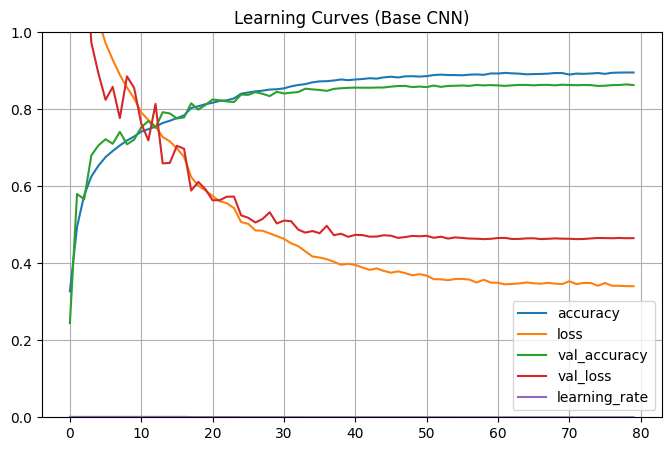

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.title("Learning Curves (Base CNN)")
plt.savefig("Learning Curves (Base CNN)")
plt.show()

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1)
])

base_transfer_model3 = keras.applications.Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(target_size, target_size, 3)  # Xception needs 71x71+
)

# base_transfer_model3.trainable = False

inputs = keras.Input(shape=(32, 32, 3))
# Resize images because Xception requires larger input
x = layers.Resizing(target_size, target_size, interpolation="bilinear", antialias=True)(inputs)
x = data_augmentation(x)
x = preprocess_input(x)

x = base_transfer_model3(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_layers, activation="softmax")(x)

base_transfer_model3 = keras.Model(inputs, outputs)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
warmup_steps = (len(x_train) * warmup_epochs) // batch_size
warmup_sched = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=base_lr, decay_steps=warmup_steps
)

optimizer = keras.optimizers.AdamW(learning_rate=warmup_sched, weight_decay=1e-4)
loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

SAVE_PATH = "/content/drive/MyDrive/xception_best_full.keras"  # full model save path
BACKUP_DIR = "/content/drive/MyDrive/xception_training_backup"

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath=SAVE_PATH, monitor="val_accuracy", save_best_only=True, save_weights_only=False, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.BackupAndRestore(backup_dir=BACKUP_DIR, save_freq="epoch")
]


base_transfer_model3.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
history = base_transfer_model3.fit(x_train, y_train, epochs=warmup_epochs, batch_size=64, validation_split=0.1)

base_transfer_model3.trainable = True
freeze_bn = lambda layer: isinstance(layer, layers.BatchNormalization)

for layer in base_transfer_model3.layers:
    if freeze_bn(layer):
        layer.trainable = False

# Optionally only unfreeze late layers:
for layer in base_transfer_model3.layers[:-36]:
    layer.trainable = False

# New (lower) LR + cosine decay for fine-tuning
ft_steps = (len(x_train) * ft_epochs) // batch_size
ft_sched = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=ft_lr, decay_steps=ft_steps
)
ft_opt = keras.optimizers.AdamW(learning_rate=ft_sched, weight_decay=5e-5)

base_transfer_model3.compile(optimizer=ft_opt, loss=loss, metrics=["accuracy"])

cbs_ft = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True, verbose=1),

    keras.callbacks.ModelCheckpoint(
        filepath=SAVE_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    keras.callbacks.BackupAndRestore(backup_dir=BACKUP_DIR, save_freq="epoch")
]

history_ft = base_transfer_model3.fit(
    x_train, y_train,
    initial_epoch=history.epoch[-1] + 1,
    epochs=history.epoch[-1] + 1 + ft_epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=1,
    callbacks=cbs_ft
)

test_loss, test_acc = base_transfer_model3.evaluate(x_test, y_test)
results.append({"Name": "Base Tansfer Model with larger image size", "Accuracy": float(test_acc), "Loss": float(test_loss), "Learning rate": 0.0003})
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/6
633/633 ━━━━━━━━━━━━━━━━━━━━ 687s 1s/step - accuracy: 0.7342 - loss: 0.8673 - val_accuracy: 0.1116 - val_loss: 2.4817
Epoch 2/6
633/633 ━━━━━━━━━━━━━━━━━━━━ 644s 1s/step - accuracy: 0.9126 - loss: 0.2625 - val_accuracy: 0.1098 - val_loss: 2.8875
Epoch 3/6
633/633 ━━━━━━━━━━━━━━━━━━━━ 644s 1s/step - accuracy: 0.9397 - loss: 0.1817 - val_accuracy: 0.1596 - val_loss: 2.7233
Epoch 4/6
633/633 ━━━━━━━━━━━━━━━━━━━━ 645s 1s/step - accuracy: 0.9583 - loss: 0.1229 - val_accuracy: 0.3162 - val_loss: 2.3595
Epoch 5/6
633/633 ━━━━━━━━━━━━━━━━━━━━ 644s 1s/step - accuracy: 0.9695 - loss: 0.0885 - val_accuracy: 0.3687 - val_loss: 2.6825
Epoch 6/6
633/633 ━━━━━━━━━━━━━━━━━━━━ 644s 1s/step - accuracy: 0.9803 - loss: 0.0570 - val_accuracy: 0.9618 - val_loss: 0.1146
Epoch 7/21
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 994ms/step - accuracy: 0.9831 - loss: 0.6707
Epoch 7: val_accuracy improved from -inf to 0.95089, saving model to /content/drive/MyDrive/xception_best_full.keras
633/633 ━━━━━━━━━━━━━━━━━━━

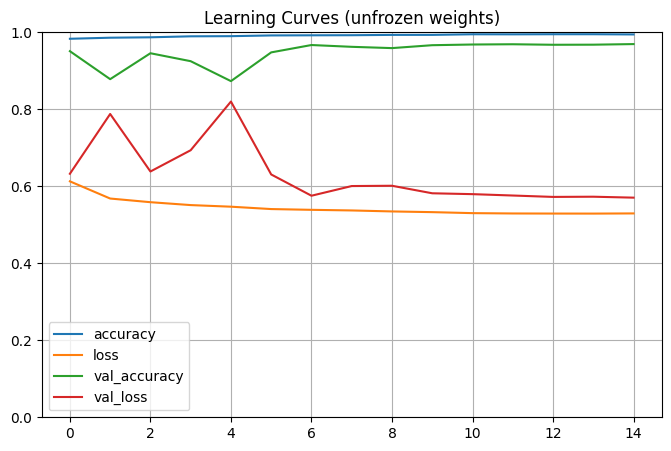

In [ ]:
pd.DataFrame(history_ft.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.title("Learning Curves (unfrozen weights)")
plt.savefig("Learning Curves (unfrozen weights).png")
plt.show()

In [ ]:
df.to_excel('transfer_model_output_Darrick_Pang.xlsx', sheet_name='MyData')

In [ ]:
df = pd.read_excel('transfer_model_output_Darrick_Pang.xlsx')
df

,Unnamed: 0,Metric,Base CNN,Xception (Pre-trained)
0,0,Test Accuracy,0.73,0.9703
1,1,Loss,0.7809,0.572413
2,2,Training time,1 hour,3 hours
3,3,Number of parameters,2279594,21925938
4,4,Input size,32 by 32,192 by 192
5,5,Pre-trained?,No,Yes


In [ ]:
print("CNN parameters:", base_cnn_model.count_params())
print("Xception parameters:", base_transfer_model3.count_params())

CNN parameters: 2279594
Xception parameters: 21925938


# 6. Report

### A. Performance Comparison

In this project, I trained a baseline CNN model and compared it to a pre-trained Xception model. Below is the comparison between the two models.

In [ ]:
df

,Unnamed: 0,Metric,Base CNN,Xception (Pre-trained)
0,0,Test Accuracy,0.73,0.9703
1,1,Loss,0.7809,0.572413
2,2,Training time,1 hour,3 hours
3,3,Number of parameters,2279594,21925938
4,4,Input size,32 by 32,192 by 192
5,5,Pre-trained?,No,Yes


### B. CNN Accuracy

For my baseline CNN, I decided to use a code that gave me an accuracy of 94 percent on the fashion MNIST data. The code for my data augmentation is
```python
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1)
])
```
which will be used for both the baseline CNN code and the transfer model. However, my accuracy was only about 73 percent.

One factor could be that the input size was 32.
```python
base_cnn_model.build(input_shape=(None, 32, 32, 3))
```
The input size can affect accuracy because the larger the image size, the more details the baseline CNN model can find. However, I had the input size at 32 so this would affect the amount of detail my CNN can find.

A second factor could be my choices for the rotations, zoom, and translations. From above, we see the rotation is 12 degrees, zoom is 15 percent, and translation is 10 percent. Our input size is 32, and such high values for zoom, rotation, and translation could remove the necessary details the CNN needs to improve accuracy. For example, I had zoom at 15 percent. Because the image's input size is 32 by 32, a 15 percent zoom means about 5 pixels are removed on both dimensions, leaving an image size of 27 by 27. The lost pixels could provide the necessary details to help improve the CNN model's accuracy because each convolutional layer relies on small visual receptive fields that are about 3 by 3 or 5 by 5 to capture local features such as edges, textures, or shapes. Such a massive drop in pixels greatly hurts the spatial resolution available to these receptive fields. When combined with translations and rotations, we could remove more pixels, and therefore, reduce the model's ability to distinguish similar objects, and ultimately lower classification accuracy. Such strong augmentation has hurt the CNN model's accuracy.

Another factor is the CIFAR-10 data has 60,000 images with 50,000 or so being trained. My CNN model is being trained from the beginning using the 50,000 images with 10 classes at a size of 32 by 32. This relatively small sample size, coupled with a small image size, means the CNN model will miss out on a lot of visual details. However, the pre-trained model Xception is trained on over one million images so that model would have been exposed to much more visual details.

An analogy is a rookie quarterback thrown immediately as a starter and having him learn how to play in the NFL, reading defenses, and understanding formations while another quarterback who has over 10 years of playing has seen so much that he is only adding to his knowledge.

### C. Transfer Model Accuracy

For my transfer model, I used the same data augmentation for my baseline CNN model with an image size 192 by 192. We also included some warmups
```python
warmup_steps = (len(x_train) * warmup_epochs) // batch_size
warmup_sched = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=base_lr, decay_steps=warmup_steps
)

optimizer = keras.optimizers.AdamW(learning_rate=warmup_sched, weight_decay=1e-4)
```
to gradually increase the learning rate because if we start it too high, the pre-trained weights may destabilize and hurt accuracy. The cosine decay is included to decay after hitting the peak learning rate to refine the pre-trained weights through fine-tuning the model, gives us a smoother convergence through gradual LR changes, and improve accuracy.

The reason why I increased image size to 192 by 192 is that there will be more spatial features for Xception to capture. In addition, Xception was trained on over one million images so larger images imply a higher accuracy.

The first six epochs are to warm up the model, just like someone at the gym is warming up with light weights before moving to heaver weights. We kept
```python
trainable = False
```
because
1. We want to maintain those features and preserve the pre-trained weights and avoid forgetting the features already extracted
2. make sure the classifiers settle down first and avoid unstable gradients or poor convergence
3. prevent gradient shocks that could hurt fine-tuned filters.

Once we finish the warmups, we can begin "lifting" heavier weights. We first begin by setting
```python
trainable  = True
```
but we do not want to train all layers as we can see from this code:
```python
for layer in base_transfer_model3.layers:
    if freeze_bn(layer):
        layer.trainable = False

# Optionally only unfreeze late layers:
for layer in base_transfer_model3.layers[:-36]:
    layer.trainable = False.
```
We want to keep the Batch Normalization frozen because we want to keep the learned mean and variance and maintain stability.

Also, we just want to fine-tune the final 36 deeper layers because these layers are the specialized layers that are needed to detect specific features such as
1. Aircraft jet engine
2. tree
3. cargo ship.

We do not need to worry about the higher layers because they are focused on generic features such as edges and corners so there is little to no benefit in training them.

One remark I want to make is that for our pre-trained model, our validation accuracy started off very low at 0.11 before jumping up to 0.37 and then to 0.96. This is expected because at the beginning, the random classifiers are acting as a feature extractor and the pre-trained convolution layers are frozen. In addition, label smoothing contributes to the slow rise by softening target labels. This step is important because it smooths out the overconfidence that while accuracy growth is slowed down in the short-term, better training stability and better generalization will occur in the longer term. Then as they adapt, the accuracy begins to go up from 0.11 to 0.36. Finally, once we unfreeze the deeper layers and the model refines the features for this dataset, the accuracy jumps even further to 0.96.

### D. Trade-offs

We can tell the Xception pre-trained model is superior because it gave me a 97 percent accuracy versus the baseline CNN that gave me a 73 percent accuracy. However, there are some sacrifices made to achieve such a high accuracy. For example, Xception needed about 22 million parameters while CNN needed a little over 2 million. More parameters mean a longer training time, and Xception needed over 3 hours of training time while CNN needed a third of that. If I were to increase the Xception accuracy to over 99 percent, I would need many more parameters and a longer training time.

### E. Concluding Remarks

1. Overall, we can see from the table above that the baseline CNN model achieved an accuracy of about 73 percent versus the pre-trained Xception model that achieved 97.03 percent.
2. CNN had 80 epochs that took about an hour to train, but Xception took over 3 hours of training time.
3. The CNN struggled because it was training on 50,000 images with a size of 32 by 32 . Xception was pre-trained on over one million images and were training on an additional 50,000 at a size of 192 by 192.

This shows that pre-trained models are superior to models that were trained from scratch. Pre-trained models use the millions of data they have learned and apply it to the CIFAR-10 images that gave the model a 97 percent accuracy using only a total of 21 epochs versus 80 for the baseline CNN. However, if my CNN model was training on over one million images, I could achieve similar accuracy as Xception, but that could require thousands of hours of training time.